# Entrenamiento y Evaluación de Modelos — Dataset UCI Colelitiasis
## Nicolas Rodriguez Forero & Fabian Rincón Suarez

---

## Índice

1. [Imports y Carga de Datos Procesados](#1-imports-y-carga-de-datos-procesados)  
2. [Definición de Modelos](#2-definición-de-modelos)  
   - 2.1 DummyClassifier (referencia mínima)  
   - 2.2 Regresión Logística (baseline)  
   - 2.3 Random Forest  
   - 2.4 Gradient Boosting  
   - 2.5 Support Vector Machine  
3. [Validación Cruzada (k=5)](#3-validación-cruzada-k5)  
   - 3.1 Métricas por fold  
   - 3.2 Tabla resumen comparativa  
   - 3.3 Boxplots de distribución por fold  
4. [Evaluación sobre Datos de Test](#4-evaluación-sobre-datos-de-test)  
   - 4.1 Classification reports  
   - 4.2 Curvas ROC  
   - 4.3 Matrices de confusión  
   - 4.4 Importancia de variables  
   - 4.5 Tabla final comparativa

---

## 1. Imports y Carga de Datos Procesados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

DOCS_PATH      = Path("../docs")
PROCESSED_PATH = Path("../data/processed")
TARGET         = "Gallstone Status"
RANDOM_STATE   = 123

In [2]:
X_train = pd.read_csv(PROCESSED_PATH / "X_train_processed.csv")
X_test  = pd.read_csv(PROCESSED_PATH / "X_test_processed.csv")
y_train = pd.read_csv(PROCESSED_PATH / "y_train.csv").squeeze()
y_test  = pd.read_csv(PROCESSED_PATH / "y_test.csv").squeeze()

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"\nClase positiva clínica: 1 = cálculo presente (enfermo)")
print(f"Train — clase 0: {(y_train==0).sum()} | clase 1: {(y_train==1).sum()}")
print(f"Test  — clase 0: {(y_test==0).sum()}  | clase 1: {(y_test==1).sum()}")

X_train: (255, 27) | y_train: (255,)
X_test:  (64, 27)  | y_test:  (64,)

Clase positiva clínica: 1 = cálculo presente (enfermo)
Train — clase 0: 129 | clase 1: 126
Test  — clase 0: 32  | clase 1: 32


---

## 2. Definición de Modelos

Se definen cinco clasificadores que cubren distintos niveles de complejidad y enfoques algorítmicos. Todos son entrenados sobre `X_train` / `y_train`; el conjunto de test se reserva para la evaluación final (Sección 4).

### 2.1 DummyClassifier — Referencia Mínima

Predice siempre la clase más frecuente. Establece el piso de rendimiento: cualquier modelo real debe superarlo.

### 2.2 Regresión Logística — Baseline

Modelo lineal interpretable. Sirve como baseline competente: simple, rápido y con buena generalización en espacios de características moderados.

### 2.3 Random Forest

Ensemble de árboles de decisión entrenados con muestras y subconjuntos de features aleatorios. Robusto frente a outliers y no requiere normalización estricta de variables.

### 2.4 Gradient Boosting

Ensemble secuencial que corrige errores del modelo anterior de forma iterativa. Generalmente alcanza alto rendimiento en datasets tabulares de tamaño moderado.

### 2.5 Support Vector Machine

Busca el hiperplano de margen máximo en el espacio de features. Con kernel RBF es efectivo en espacios de alta dimensión y con clases bien separables.

In [3]:
models = {
    "DummyClassifier":      DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Regresión Logística":  LogisticRegression(C=1, max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest":        RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                       max_depth=4, random_state=RANDOM_STATE),
    "SVM":                  SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE)
}

print(f"Modelos definidos: {list(models.keys())}")

Modelos definidos: ['DummyClassifier', 'Regresión Logística', 'Random Forest', 'Gradient Boosting', 'SVM']


---

## 3. Validación Cruzada (k=5)

Se aplica `StratifiedKFold` con 5 folds sobre el conjunto de entrenamiento. La estratificación garantiza que la proporción de cada clase se preserve en cada fold. La validación cruzada estima el rendimiento esperado del modelo sin tocar el test.

### 3.1 Métricas por Fold

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy":  "accuracy",
    "recall":    "recall",        # recall de clase 1 (pos_label=1 por defecto en sklearn)
    "precision": "precision",
    "f1":        "f1",
    "roc_auc":   "roc_auc"
}

cv_results = {}

for name, model in models.items():
    print(f"Evaluando: {name}...", end=" ")
    scores = cross_validate(model, X_train, y_train, cv=cv,
                            scoring=scoring, return_train_score=False, n_jobs=-1)
    cv_results[name] = scores
    print("OK")

print("\nValidación cruzada completada.")

Evaluando: DummyClassifier... OK
Evaluando: Regresión Logística... OK
Evaluando: Random Forest... OK
Evaluando: Gradient Boosting... OK
Evaluando: SVM... OK

Validación cruzada completada.


### 3.2 Tabla Resumen Comparativa

In [5]:
metric_map = {
    "test_accuracy":  "Accuracy",
    "test_recall":    "Recall",
    "test_precision": "Precision",
    "test_f1":        "F1",
    "test_roc_auc":   "ROC-AUC"
}

summary_rows = []
for name, scores in cv_results.items():
    row = {"Modelo": name}
    for key, label in metric_map.items():
        vals = scores[key]
        row[label] = f"{vals.mean():.3f} ± {vals.std():.3f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Modelo")
print("Resultados de Validación Cruzada (media ± desviación estándar sobre 5 folds):")
summary_df

Resultados de Validación Cruzada (media ± desviación estándar sobre 5 folds):


,Accuracy,Recall,Precision,F1,ROC-AUC
Modelo,,,,,
DummyClassifier,0.506 ± 0.008,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000
Regresión Logística,0.765 ± 0.039,0.722 ± 0.068,0.784 ± 0.035,0.751 ± 0.048,0.841 ± 0.041
Random Forest,0.753 ± 0.040,0.698 ± 0.092,0.781 ± 0.046,0.733 ± 0.056,0.834 ± 0.025
Gradient Boosting,0.761 ± 0.029,0.714 ± 0.087,0.792 ± 0.062,0.745 ± 0.041,0.833 ± 0.019
SVM,0.698 ± 0.027,0.667 ± 0.053,0.706 ± 0.017,0.685 ± 0.033,0.773 ± 0.042


### 3.3 Boxplots de Distribución por Fold

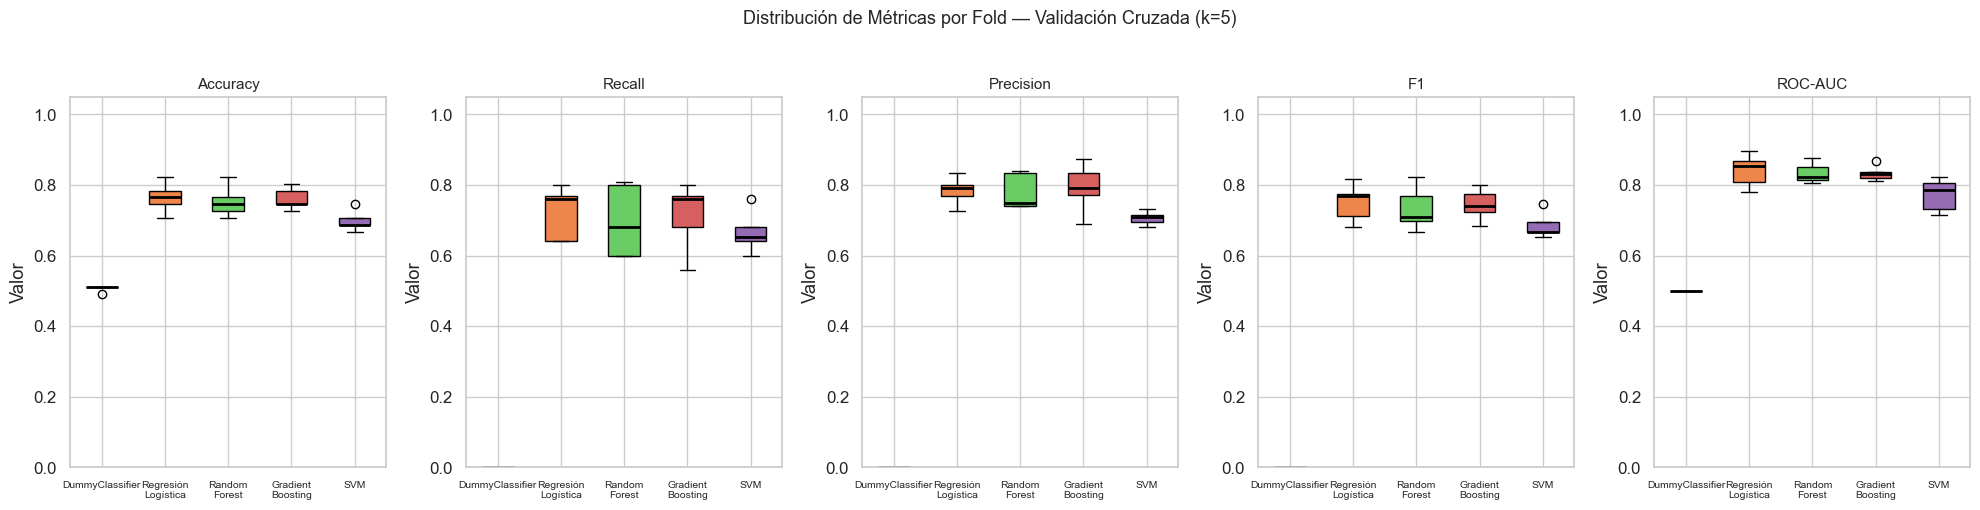

In [6]:
metrics_to_plot = ["test_accuracy", "test_recall", "test_precision", "test_f1", "test_roc_auc"]
metric_labels   = ["Accuracy", "Recall", "Precision", "F1", "ROC-AUC"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

palette = sns.color_palette("muted", n_colors=len(models))

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    data = [cv_results[name][metric] for name in models]
    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], palette):
        patch.set_facecolor(color)
    ax.set_xticks(range(1, len(models) + 1))
    ax.set_xticklabels(
        [n.replace(" ", "\n") for n in models.keys()],
        fontsize=7.5
    )
    ax.set_title(label, fontsize=11)
    ax.set_ylabel("Valor")
    ax.set_ylim(0, 1.05)

fig.suptitle("Distribución de Métricas por Fold — Validación Cruzada (k=5)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_PATH / "cv_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 4. Evaluación sobre Datos de Test

Los modelos se reentrenan sobre la totalidad del conjunto de entrenamiento y se evalúan **una única vez** sobre el test. Esta evaluación final representa el rendimiento esperado en producción sobre datos no vistos.

In [7]:
# Reentrenar todos los modelos sobre el train completo
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f"Entrenado: {name}")

Entrenado: DummyClassifier
Entrenado: Regresión Logística
Entrenado: Random Forest
Entrenado: Gradient Boosting
Entrenado: SVM


### 4.1 Classification Reports

Recuerdo de la codificación: clase 0 = sano, **clase 1 = cálculo presente (enfermo)**. El recall de la clase 1 es la métrica primaria clínica.

In [8]:
for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'=' * 55}")
    print(f"Modelo: {name}")
    print(f"{'=' * 55}")
    print(classification_report(
        y_test, y_pred,
        target_names=["Clase 0 (Sano)", "Clase 1 (Enfermo)"]
    ))


Modelo: DummyClassifier
                   precision    recall  f1-score   support

   Clase 0 (Sano)       0.50      1.00      0.67        32
Clase 1 (Enfermo)       0.00      0.00      0.00        32

         accuracy                           0.50        64
        macro avg       0.25      0.50      0.33        64
     weighted avg       0.25      0.50      0.33        64


Modelo: Regresión Logística
                   precision    recall  f1-score   support

   Clase 0 (Sano)       0.71      0.69      0.70        32
Clase 1 (Enfermo)       0.70      0.72      0.71        32

         accuracy                           0.70        64
        macro avg       0.70      0.70      0.70        64
     weighted avg       0.70      0.70      0.70        64


Modelo: Random Forest
                   precision    recall  f1-score   support

   Clase 0 (Sano)       0.74      0.78      0.76        32
Clase 1 (Enfermo)       0.77      0.72      0.74        32

         accuracy             

c:\Users\Gizmo\Desktop\Dev\university-projects\semestre-9\modelos_predictivos\pred_models-1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Gizmo\Desktop\Dev\university-projects\semestre-9\modelos_predictivos\pred_models-1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Gizmo\Desktop\Dev\university-projects\semestre-9\modelos_predictivos\pred_models-1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined 

### 4.2 Curvas ROC

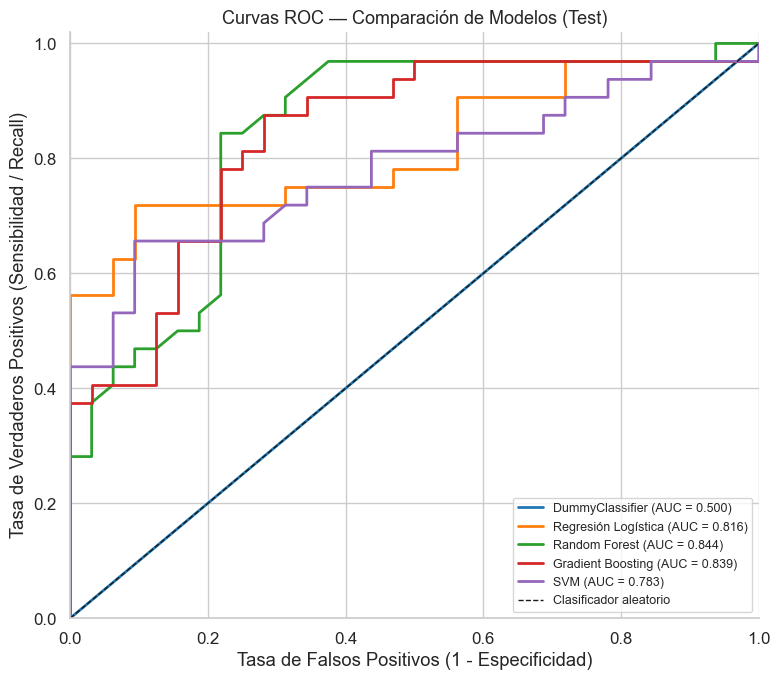

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))

colors_roc = sns.color_palette("tab10", n_colors=len(fitted_models))

for (name, model), color in zip(fitted_models.items(), colors_roc):
    if hasattr(model, "predict_proba"):
        # pos_label=1: clase positiva clínica es la 1 (enfermo)
        y_prob = model.predict_proba(X_test)[:, 1]  # prob de clase 1
        fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad / Recall)")
ax.set_title("Curvas ROC — Comparación de Modelos (Test)", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
sns.despine()
plt.tight_layout()
plt.savefig(DOCS_PATH / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Matrices de Confusión

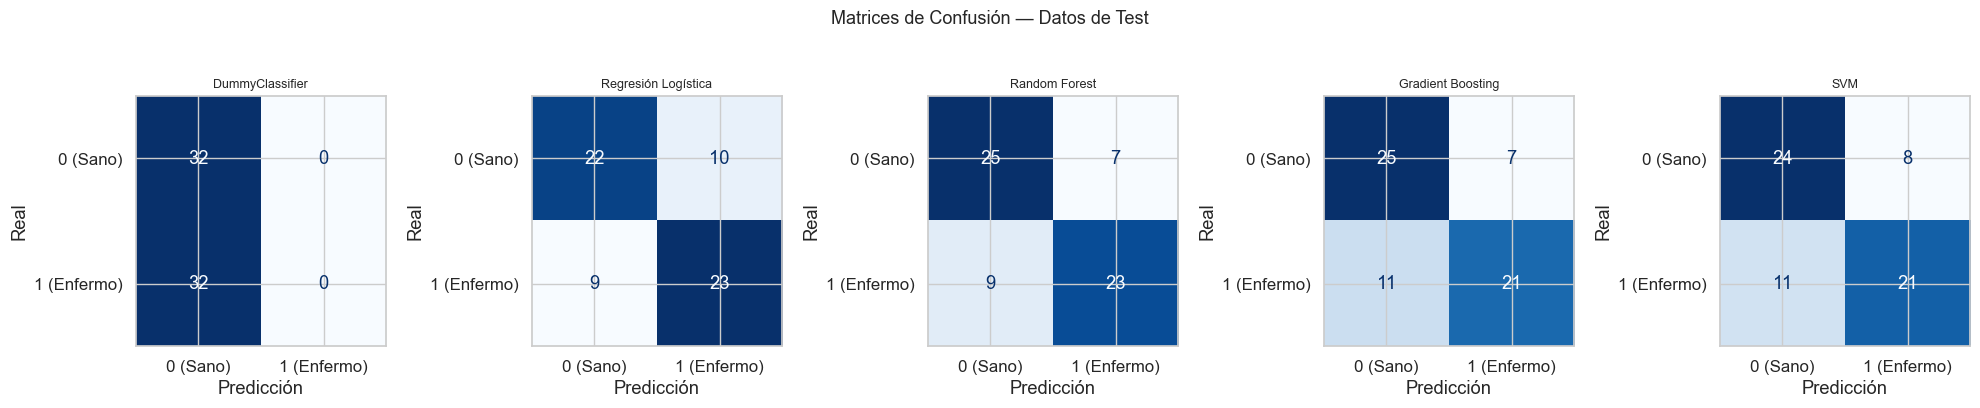

In [10]:
n_models = len(fitted_models)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["0 (Sano)", "1 (Enfermo)"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

fig.suptitle("Matrices de Confusión — Datos de Test", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_PATH / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.4 Importancia de Variables

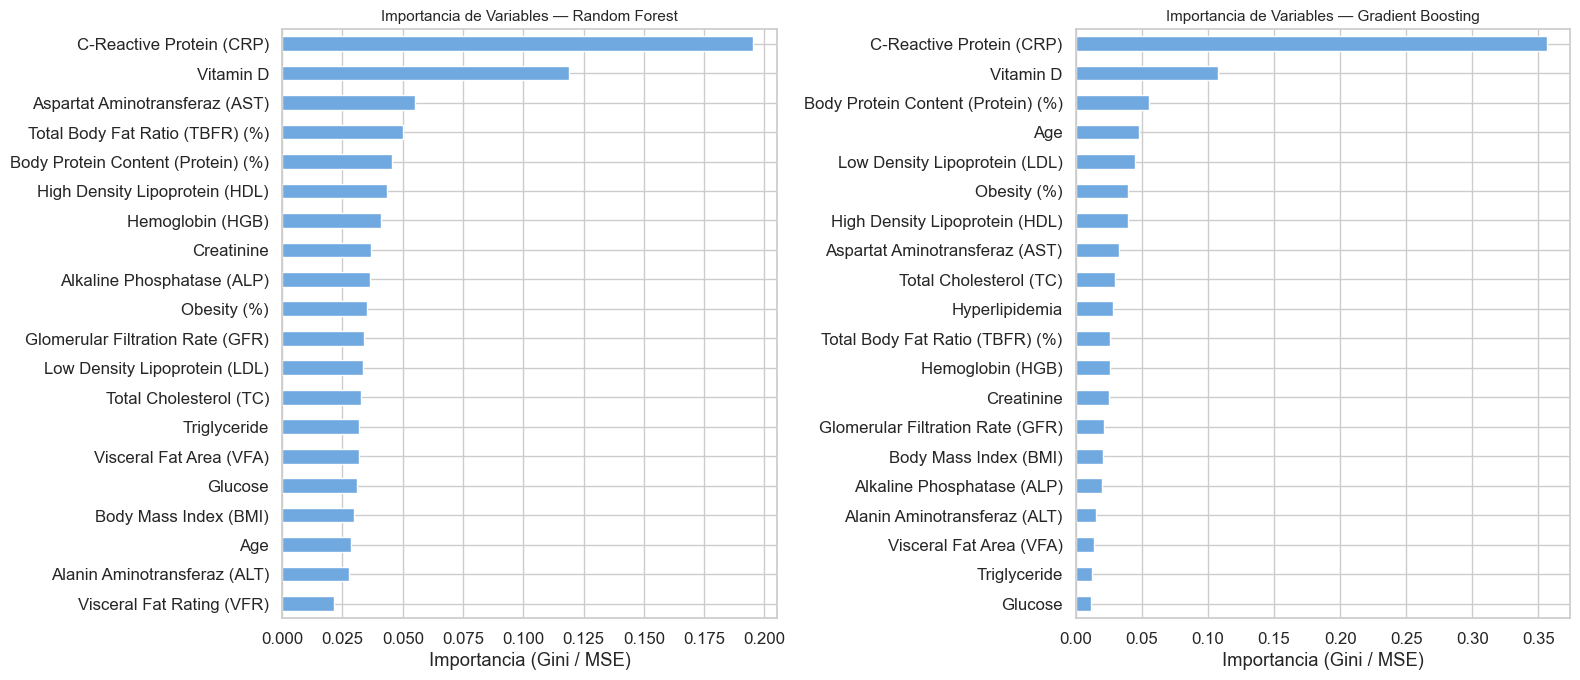

In [11]:
feature_names = X_train.columns.tolist()
tree_models = {
    k: v for k, v in fitted_models.items()
    if hasattr(v, "feature_importances_")
}

fig, axes = plt.subplots(1, len(tree_models), figsize=(8 * len(tree_models), 7))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, tree_models.items()):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True).tail(20)

    importances.plot(
        kind="barh", ax=ax,
        color="#70A8E0", edgecolor="white"
    )
    ax.set_title(f"Importancia de Variables — {name}", fontsize=11)
    ax.set_xlabel("Importancia (Gini / MSE)")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(DOCS_PATH / "feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.5 Tabla Final Comparativa

Resumen de métricas sobre el conjunto de test. El **Recall (clase 1)** es la métrica prioritaria desde la perspectiva clínica: minimizar los falsos negativos (cálculos no detectados) es la consideración más crítica en este contexto.

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_rows = []
for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    row = {
        "Modelo":             name,
        "Accuracy":           accuracy_score(y_test, y_pred),
        "Recall (clase 1)":   recall_score(y_test, y_pred, pos_label=1),
        "Precision (clase 1)": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "F1 (clase 1)":       f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "ROC-AUC":            roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    }
    test_rows.append(row)

test_df = pd.DataFrame(test_rows).set_index("Modelo").round(3)

# Resaltar mejor valor por columna
print("Tabla de Métricas — Datos de Test")
print("(Métrica primaria clínica: Recall clase 1 — cálculo presente)")
print()
test_df

Tabla de Métricas — Datos de Test
(Métrica primaria clínica: Recall clase 1 — cálculo presente)



,Accuracy,Recall (clase 1),Precision (clase 1),F1 (clase 1),ROC-AUC
Modelo,,,,,
DummyClassifier,0.500,0.000,0.000,0.000,0.500
Regresión Logística,0.703,0.719,0.697,0.708,0.816
Random Forest,0.750,0.719,0.767,0.742,0.844
Gradient Boosting,0.719,0.656,0.750,0.700,0.839
SVM,0.703,0.656,0.724,0.689,0.783


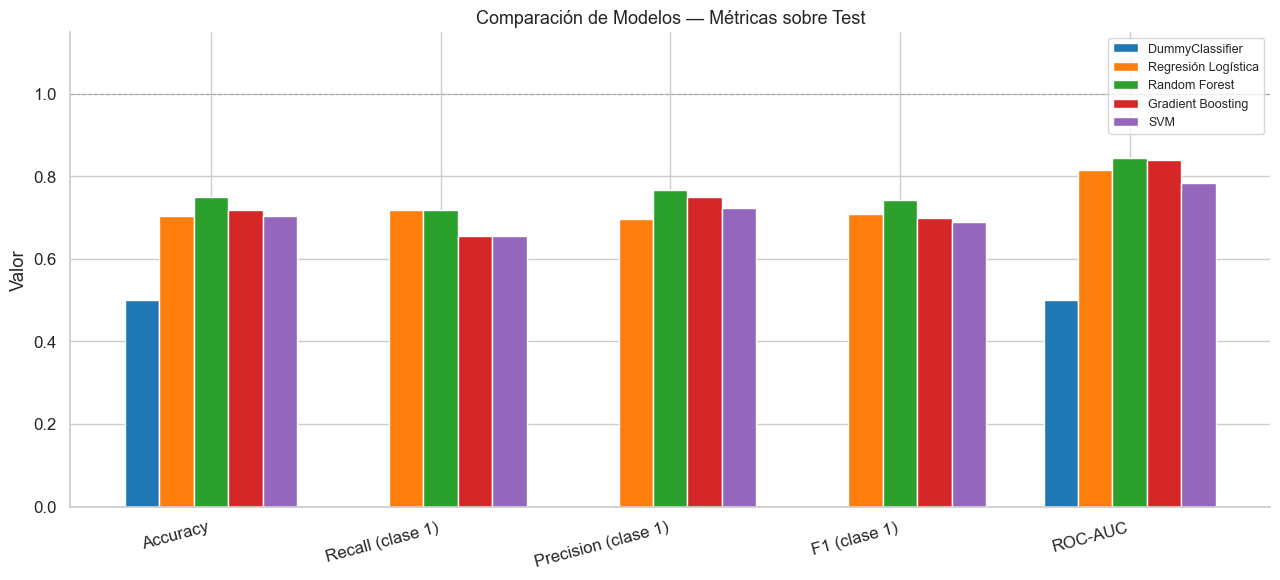

In [13]:
# Visualización de la tabla como gráfico de barras comparativo
metrics_bar = ["Accuracy", "Recall (clase 1)", "Precision (clase 1)", "F1 (clase 1)", "ROC-AUC"]

x = np.arange(len(metrics_bar))
width = 0.15
palette_bar = sns.color_palette("tab10", n_colors=len(fitted_models))

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, row) in enumerate(test_df.iterrows()):
    offset = (i - len(fitted_models) / 2 + 0.5) * width
    vals = [row[m] for m in metrics_bar]
    ax.bar(x + offset, vals, width=width, label=name,
           color=palette_bar[i], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(metrics_bar, rotation=15, ha="right")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1.15)
ax.set_title("Comparación de Modelos — Métricas sobre Test", fontsize=13)
ax.legend(loc="upper right", fontsize=9)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
sns.despine()
plt.tight_layout()
plt.savefig(DOCS_PATH / "test_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Identificar el modelo con mayor Recall (clase 1)
best_model = test_df["Recall (clase 1)"].idxmax()
best_recall = test_df.loc[best_model, "Recall (clase 1)"]
dummy_recall = test_df.loc["DummyClassifier", "Recall (clase 1)"]

print(f"Modelo con mayor Recall (clase 1): {best_model} — {best_recall:.3f}")
print(f"Recall del DummyClassifier:         {dummy_recall:.3f}")
print(f"Mejora sobre la referencia mínima:  {best_recall - dummy_recall:+.3f}")

print("\n--- Tabla final ordenada por Recall (clase 1) ---")
test_df.sort_values("Recall (clase 1)", ascending=False)

Modelo con mayor Recall (clase 1): Regresión Logística — 0.719
Recall del DummyClassifier:         0.000
Mejora sobre la referencia mínima:  +0.719

--- Tabla final ordenada por Recall (clase 1) ---


,Accuracy,Recall (clase 1),Precision (clase 1),F1 (clase 1),ROC-AUC
Modelo,,,,,
Regresión Logística,0.703,0.719,0.697,0.708,0.816
Random Forest,0.750,0.719,0.767,0.742,0.844
Gradient Boosting,0.719,0.656,0.750,0.700,0.839
SVM,0.703,0.656,0.724,0.689,0.783
DummyClassifier,0.500,0.000,0.000,0.000,0.500
